In [1]:
# PropTech CABA - Análisis Espacial
# GeoPandas + OSMnx + ARG.csv
# Marzo 2026

In [2]:
import os

# Busca ARG.csv en todo el disco del usuario
for root, dirs, files in os.walk(r'C:\Users\linoc'):
    for file in files:
        if 'ARG' in file.upper() and file.endswith('.csv'):
            print(os.path.join(root, file))

C:\Users\linoc\Desktop\Proyecto Proptech\Dashboard-proptech-bsas\inflacion_argentina_2020_2025.csv
C:\Users\linoc\Desktop\Proyecto Proptech\Dashboard-proptech-bsas\TABLEAU_barrios_ARG.csv
C:\Users\linoc\Desktop\Proyecto Proptech\Dashboard-proptech-bsas\CSVs_Corregidos_Tableau\inflacion_argentina_2020_2025.csv
C:\Users\linoc\Desktop\Proyecto Proptech\Dashboard-proptech-bsas\CSVs_Corregidos_Tableau\TABLEAU_barrios_ARG.csv
C:\Users\linoc\Desktop\Proyecto Proptech\Dashboard-proptech-bsas\CSVs_Originales_Backup\inflacion_argentina_2020_2025.csv
C:\Users\linoc\Desktop\Proyecto Proptech\Dashboard-proptech-bsas\CSVs_Originales_Backup\TABLEAU_barrios_ARG.csv
C:\Users\linoc\Desktop\TODO DATOS\energia_argentina.csv
C:\Users\linoc\Downloads\TABLEAU_barrios_ARG.csv


In [3]:
import pandas as pd

ruta = r'C:\Users\linoc\Desktop\Proyecto Proptech\Dashboard-proptech-bsas\CSVs_Corregidos_Tableau\TABLEAU_barrios_ARG.csv'

df = pd.read_csv(ruta, sep=';')
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(55, 15)
['barrio', 'cantidad', 'precio_m2', 'precio_mediana', 'rentabilidad_bruta', 'indice_socioeconomico', 'factor_blanqueo', 'lat', 'lon', 'roi_promedio', 'prob_positivo', 'sharpe_ratio', 'score_inversion', 'categoria', 'ranking_posicion']
   barrio   cantidad  precio_m2  precio_mediana  rentabilidad_bruta  \
0       2  Económico          1             NaN                 NaN   
1       7  Económico          2             NaN                 NaN   
2       4      Medio          3             NaN                 NaN   

   indice_socioeconomico  factor_blanqueo  lat  lon  roi_promedio  \
0                    NaN              NaN  NaN  NaN           NaN   
1                    NaN              NaN  NaN  NaN           NaN   
2                    NaN              NaN  NaN  NaN           NaN   

   prob_positivo  sharpe_ratio  score_inversion  categoria  ranking_posicion  
0            NaN           NaN              NaN        NaN               NaN  
1            NaN           NaN      

In [4]:
# Probamos separadores distintos
df = pd.read_csv(ruta, sep=',')
print(df.shape)
print(df.head(3))

(55, 1)
  barrio;cantidad;precio_m2;precio_mediana;rentabilidad_bruta;indice_socioeconomico;factor_blanqueo;lat;lon;roi_promedio;prob_positivo;sharpe_ratio;score_inversion;categoria;ranking_posicion
0                                      2;Económico;1                                                                                                                                          
1                                      7;Económico;2                                                                                                                                          
2                                          4;Medio;3                                                                                                                                          


In [5]:
# Ver las primeras líneas tal cual están en el archivo
with open(ruta, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line)
        if i > 4:
            break

﻿barrio;cantidad;precio_m2;precio_mediana;rentabilidad_bruta;indice_socioeconomico;factor_blanqueo;lat;lon;roi_promedio;prob_positivo;sharpe_ratio;score_inversion;categoria;ranking_posicion

2;Económico;1

7;Económico;2

4;Medio;3

7;Económico;4

5;Económico;5



In [6]:
ruta2 = r'C:\Users\linoc\Downloads\TABLEAU_barrios_ARG.csv'

# Leemos bien con sep correcto y encoding
df = pd.read_csv(ruta2, sep=';', encoding='utf-8')
print(df.shape)
print(df.columns.tolist())
print(df.head(5))

(55, 15)
['barrio', 'cantidad', 'precio_m2', 'precio_mediana', 'rentabilidad_bruta', 'indice_socioeconomico', 'factor_blanqueo', 'lat', 'lon', 'roi_promedio', 'prob_positivo', 'sharpe_ratio', 'score_inversion', 'categoria', 'ranking_posicion']
      barrio  cantidad precio_m2 precio_mediana rentabilidad_bruta  \
0     Abasto       305    2695,0       132980,0                4,8   
1  Agronomía       168    2687,0       158599,5                4,8   
2    Almagro      5655    2827,0       162260,0                4,8   
3  Balvanera      2163    2213,0       132980,0                4,8   
4   Barracas       905    2562,0       179340,0                4,8   

  indice_socioeconomico factor_blanqueo     lat     lon roi_promedio  \
0                 31,61             0,0   -34,6  -58,41         12,3   
1                 34,81             0,0   -34,6  -58,49         17,5   
2                 40,44             0,5  -34,61  -58,42         24,6   
3                 31,61             0,5  -34,61

In [7]:
import os

# Carpeta del proyecto
BASE = r'C:\Users\linoc\Desktop\CABATECH'
os.makedirs(BASE, exist_ok=True)

# Guardar GeoJSON
caba.to_file(os.path.join(BASE, 'caba_48_barrios.geojson'), driver='GeoJSON')
print("Guardado: caba_48_barrios.geojson")

# Guardar imagen
plt.savefig(os.path.join(BASE, 'caba_48_barrios.png'), dpi=150, bbox_inches='tight')
print("Guardado: caba_48_barrios.png")

NameError: name 'caba' is not defined

Descargando barrios...
Barrios cargados: 48
Guardado: caba_48_barrios.geojson


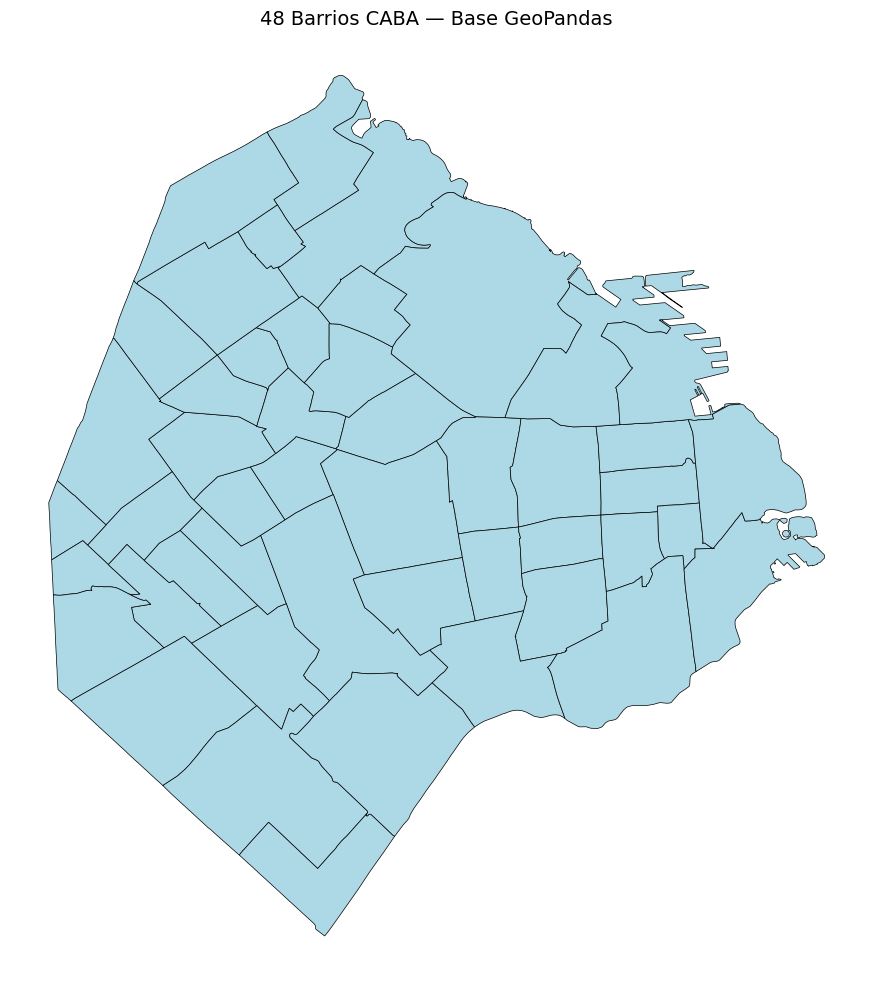

Todo guardado en CABATECH ✓


In [8]:
import geopandas as gpd
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
import os

# Carpeta proyecto
BASE = r'C:\Users\linoc\Desktop\CABATECH'
os.makedirs(BASE, exist_ok=True)

# Descarga polígonos
print("Descargando barrios...")
barrios_poly = ox.features_from_place(
    "Ciudad Autónoma de Buenos Aires, Argentina",
    tags={"boundary": "administrative", "admin_level": "10"}
)
barrios_poly = barrios_poly[barrios_poly.geometry.type.isin(['Polygon', 'MultiPolygon'])]

# 48 barrios oficiales
BARRIOS_CABA = [
    'Agronomía', 'Almagro', 'Balvanera', 'Barracas', 'Belgrano',
    'Boedo', 'Caballito', 'Chacarita', 'Coghlan', 'Colegiales',
    'Constitución', 'Flores', 'Floresta', 'La Boca', 'Liniers',
    'Mataderos', 'Monserrat', 'Monte Castro', 'Nueva Pompeya', 'Núñez',
    'Palermo', 'Parque Avellaneda', 'Parque Chacabuco', 'Parque Chas',
    'Parque Patricios', 'La Paternal', 'Puerto Madero', 'Recoleta',
    'Retiro', 'Saavedra', 'San Cristóbal', 'San Nicolás', 'San Telmo',
    'Vélez Sarsfield', 'Versalles', 'Villa Crespo', 'Villa del Parque',
    'Villa Devoto', 'Villa General Mitre', 'Villa Lugano', 'Villa Luro',
    'Villa Ortúzar', 'Villa Pueyrredón', 'Villa Real', 'Villa Riachuelo',
    'Villa Santa Rita', 'Villa Soldati', 'Villa Urquiza'
]

# Filtro y limpieza
caba = barrios_poly[barrios_poly['name'].isin(BARRIOS_CABA)][['name', 'geometry']].reset_index(drop=True)
caba = caba.rename(columns={'name': 'barrio'})
caba = caba.to_crs(epsg=4326)
print(f"Barrios cargados: {len(caba)}")

# Guardar GeoJSON
caba.to_file(os.path.join(BASE, 'caba_48_barrios.geojson'), driver='GeoJSON')
print("Guardado: caba_48_barrios.geojson")

# Mapa
fig, ax = plt.subplots(figsize=(10, 10))
caba.plot(ax=ax, edgecolor='black', color='lightblue', linewidth=0.5)
ax.set_title("48 Barrios CABA — Base GeoPandas", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'caba_48_barrios.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Todo guardado en CABATECH ✓")